# **Libraries**

In [80]:

import pandas as pd
import numpy as np
import os 
import tensorflow as tf
import seaborn as sns
import matplotlib.pyplot as plt
from PIL import Image
from scipy.stats import skew, norm
from sklearn.metrics import r2_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator



In [81]:
df = pd.read_csv("data/train.csv")

In [82]:
df["full_image_path"] = df["image_path"].apply(
    lambda x: os.path.join("data", x)
)

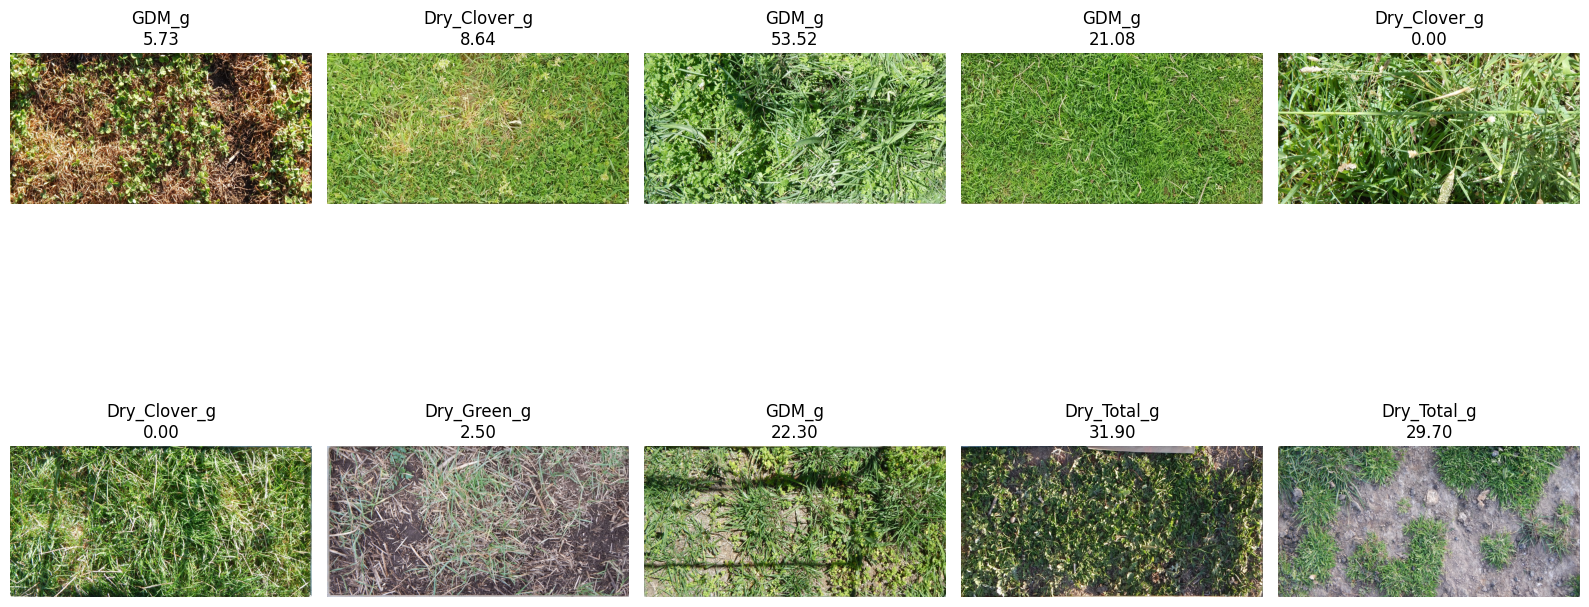

In [83]:
samples = df.sample(10, random_state=42)

plt.figure(figsize=(16, 10))

for i, (_,row) in enumerate(samples.iterrows()):
    img = Image.open(row["full_image_path"])
    plt.subplot(2, 5, i + 1)
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"{row['target_name']}\n{row['target']:.2f}")
    
plt.tight_layout()
plt.show()

In [84]:
df.columns

Index(['sample_id', 'image_path', 'Sampling_Date', 'State', 'Species',
       'Pre_GSHH_NDVI', 'Height_Ave_cm', 'target_name', 'target',
       'full_image_path'],
      dtype='object')

In [85]:
df.head()

,sample_id,image_path,Sampling_Date,State,Species,Pre_GSHH_NDVI,Height_Ave_cm,target_name,target,full_image_path
0,ID1011485656__Dry_Clover_g,train/ID1011485656.jpg,2015/9/4,Tas,Ryegrass_Clover,0.62,4.6667,Dry_Clover_g,0.0000,data\train/ID1011485656.jpg
1,ID1011485656__Dry_Dead_g,train/ID1011485656.jpg,2015/9/4,Tas,Ryegrass_Clover,0.62,4.6667,Dry_Dead_g,31.9984,data\train/ID1011485656.jpg
2,ID1011485656__Dry_Green_g,train/ID1011485656.jpg,2015/9/4,Tas,Ryegrass_Clover,0.62,4.6667,Dry_Green_g,16.2751,data\train/ID1011485656.jpg
3,ID1011485656__Dry_Total_g,train/ID1011485656.jpg,2015/9/4,Tas,Ryegrass_Clover,0.62,4.6667,Dry_Total_g,48.2735,data\train/ID1011485656.jpg
4,ID1011485656__GDM_g,train/ID1011485656.jpg,2015/9/4,Tas,Ryegrass_Clover,0.62,4.6667,GDM_g,16.2750,data\train/ID1011485656.jpg


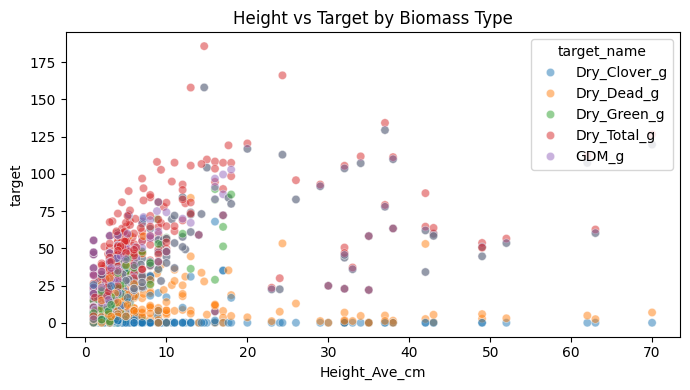

In [86]:

plt.figure(figsize=(7,4))
sns.scatterplot(
    data=df,
    x='Height_Ave_cm',
    y='target',
    hue='target_name',
    alpha=0.5
)
plt.title('Height vs Target by Biomass Type')
plt.tight_layout()
plt.show()


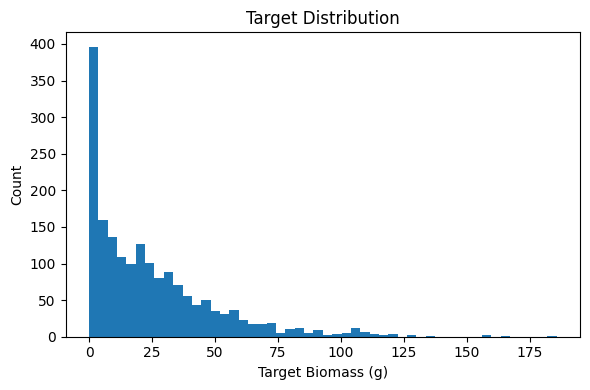

In [87]:
plt.figure(figsize=(6,4))
plt.hist(df['target'], bins=50)
plt.xlabel('Target Biomass (g)')
plt.ylabel('Count')
plt.title('Target Distribution')
plt.tight_layout()
plt.show()


In [88]:
print("skewness: ", skew(df['target']))

skewness:  1.7052914070625924


In [89]:
for name in df['target_name'].unique():
    s = skew(df[df['target_name'] == name]['target'])
    print(f"skewness of {name}: ", s)

skewness of Dry_Clover_g:  2.8300272961733346
skewness of Dry_Dead_g:  1.7539574253214023
skewness of Dry_Green_g:  1.7440778846593377
skewness of Dry_Total_g:  1.4225166978024844
skewness of GDM_g:  1.5524745817715981


In [90]:
df['target_log'] = np.log1p(df['target'])

for name in df['target_name'].unique():
    s = skew(df[df['target_name']==name]['target_log'])
    print(name, "log-skew:", s)


Dry_Clover_g log-skew: 0.6868860315134996
Dry_Dead_g log-skew: -0.42437358929029567
Dry_Green_g log-skew: -0.836750639012091
Dry_Total_g log-skew: -0.6879003932284768
GDM_g log-skew: -0.46389548085472154


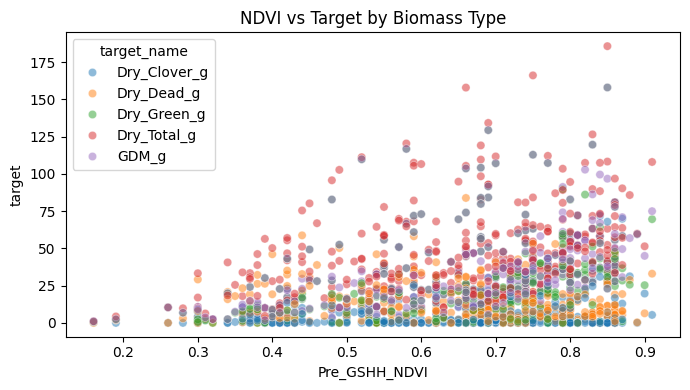

In [91]:
plt.figure(figsize=(7,4))
sns.scatterplot(
    data=df,
    x='Pre_GSHH_NDVI',
    y='target',
    hue='target_name',
    alpha=0.5
)
plt.title('NDVI vs Target by Biomass Type')
plt.tight_layout()
plt.show()


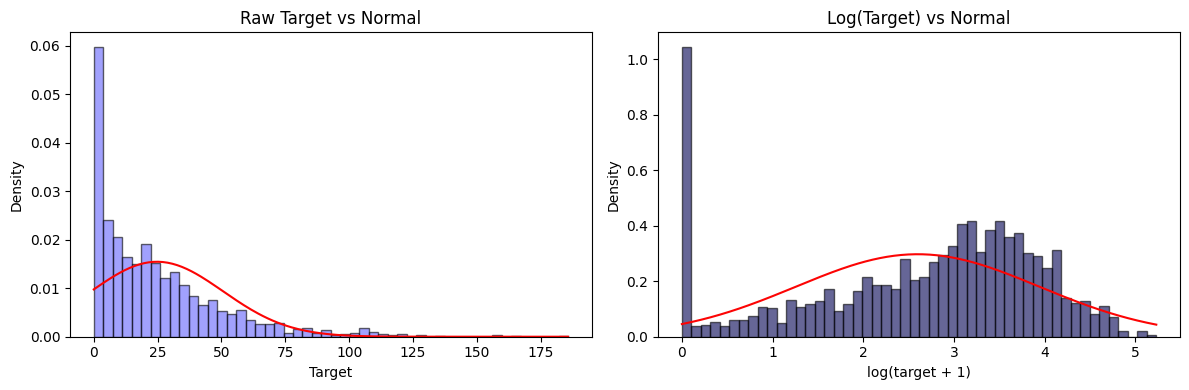

In [92]:

plt.figure(figsize=(12,4))

# ---- Raw target ----
plt.subplot(1,2,1)
data = df['target']
mu, std = data.mean(), data.std()

plt.hist(data, bins=50, density=True, alpha=0.6, color = '#6262FC', edgecolor='black')
x = np.linspace(data.min(), data.max(), 200)
plt.plot(x, norm.pdf(x, mu, std), color="#FC0404")
plt.title('Raw Target vs Normal')
plt.xlabel('Target')
plt.ylabel('Density')

# ---- Log target ----
plt.subplot(1,2,2)
data_log = df['target_log']
mu, std = data_log.mean(), data_log.std()

plt.hist(data_log, bins=50, density=True, alpha=0.6,color='#000052', edgecolor='black')
x = np.linspace(data_log.min(), data_log.max(), 200)
plt.plot(x, norm.pdf(x, mu, std), color="#FC0404")
plt.title('Log(Target) vs Normal')
plt.xlabel('log(target + 1)')
plt.ylabel('Density')

plt.tight_layout()
plt.show()

In [93]:
TABULAR_COLS = [
    'Pre_GSHH_NDVI',
    'Height_Ave_cm'
]

target_dummies = pd.get_dummies(df['target_name'], prefix='tgt')
df = pd.concat([df, target_dummies], axis=1)

TABULAR_COLS += list(target_dummies.columns)

In [94]:
df[TABULAR_COLS] = (
    df[TABULAR_COLS]
    .fillna(0)
    .astype('float32')
)


df['target_log'] = df['target_log'].astype('float32')
df['full_image_path'] = df['full_image_path'].astype(str)


In [95]:
df = pd.get_dummies(df, columns=['State', 'Species'], prefix=['state','species'], dtype=float)
TABULAR_COLS += list(df.filter(regex='^state_|^species_').columns)
df['Sampling_Date'] = pd.to_datetime(df['Sampling_Date'])

# Example features
df['year'] = df['Sampling_Date'].dt.year
df['month'] = df['Sampling_Date'].dt.month
df['day'] = df['Sampling_Date'].dt.day
df['day_of_year'] = df['Sampling_Date'].dt.dayofyear
TABULAR_COLS += ['year', 'month', 'day', 'day_of_year']
print("Final tabular columns:", TABULAR_COLS)

Final tabular columns: ['Pre_GSHH_NDVI', 'Height_Ave_cm', 'tgt_Dry_Clover_g', 'tgt_Dry_Dead_g', 'tgt_Dry_Green_g', 'tgt_Dry_Total_g', 'tgt_GDM_g', 'state_NSW', 'state_Tas', 'state_Vic', 'state_WA', 'species_Clover', 'species_Fescue', 'species_Fescue_CrumbWeed', 'species_Lucerne', 'species_Mixed', 'species_Phalaris', 'species_Phalaris_BarleyGrass_SilverGrass_SpearGrass_Clover_Capeweed', 'species_Phalaris_Clover', 'species_Phalaris_Clover_Ryegrass_Barleygrass_Bromegrass', 'species_Phalaris_Ryegrass_Clover', 'species_Ryegrass', 'species_Ryegrass_Clover', 'species_SubcloverDalkeith', 'species_SubcloverLosa', 'species_WhiteClover', 'year', 'month', 'day', 'day_of_year']


In [96]:
# One-hot encode year and month
df = pd.get_dummies(df, columns=['year','month'], prefix=['year','month'], dtype=float)

TABULAR_COLS += list(df.filter(regex='^year_|^month_').columns)
NUMERIC_COLS = ['Pre_GSHH_NDVI', 'Height_Ave_cm']
scaler = MinMaxScaler()
df['day_of_year'] = scaler.fit_transform(df[['day_of_year']])
df[NUMERIC_COLS] = scaler.fit_transform(df[NUMERIC_COLS])


In [97]:
for col in ['year', 'month', 'day']:
    if col in TABULAR_COLS:
        TABULAR_COLS.remove(col)


In [98]:
print(df[TABULAR_COLS].head())

   Pre_GSHH_NDVI  Height_Ave_cm  tgt_Dry_Clover_g  tgt_Dry_Dead_g  \
0       0.613333       0.053141               1.0             0.0   
1       0.613333       0.053141               0.0             1.0   
2       0.613333       0.053141               0.0             0.0   
3       0.613333       0.053141               0.0             0.0   
4       0.613333       0.053141               0.0             0.0   

   tgt_Dry_Green_g  tgt_Dry_Total_g  tgt_GDM_g  state_NSW  state_Tas  \
0              0.0              0.0        0.0        0.0        1.0   
1              0.0              0.0        0.0        0.0        1.0   
2              1.0              0.0        0.0        0.0        1.0   
3              0.0              1.0        0.0        0.0        1.0   
4              0.0              0.0        1.0        0.0        1.0   

   state_Vic  ...  month_1  month_2  month_4  month_5  month_6  month_7  \
0        0.0  ...      0.0      0.0      0.0      0.0      0.0      0.0   
1 

In [99]:
df.head()

,sample_id,image_path,Sampling_Date,Pre_GSHH_NDVI,Height_Ave_cm,target_name,target,full_image_path,target_log,tgt_Dry_Clover_g,...,month_1,month_2,month_4,month_5,month_6,month_7,month_8,month_9,month_10,month_11
0,ID1011485656__Dry_Clover_g,train/ID1011485656.jpg,2015-09-04,0.613333,0.053141,Dry_Clover_g,0.0000,data\train/ID1011485656.jpg,0.000000,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,ID1011485656__Dry_Dead_g,train/ID1011485656.jpg,2015-09-04,0.613333,0.053141,Dry_Dead_g,31.9984,data\train/ID1011485656.jpg,3.496459,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,ID1011485656__Dry_Green_g,train/ID1011485656.jpg,2015-09-04,0.613333,0.053141,Dry_Green_g,16.2751,data\train/ID1011485656.jpg,2.849266,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,ID1011485656__Dry_Total_g,train/ID1011485656.jpg,2015-09-04,0.613333,0.053141,Dry_Total_g,48.2735,data\train/ID1011485656.jpg,3.897386,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,ID1011485656__GDM_g,train/ID1011485656.jpg,2015-09-04,0.613333,0.053141,GDM_g,16.2750,data\train/ID1011485656.jpg,2.849260,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [100]:
train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df['target_name']
)

In [101]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32


In [102]:
def load_image(path):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    img = img / 255.0
    return img

In [103]:
def make_dataset(df, training= True):
    img_paths = df['full_image_path'].values
    tabular = df[TABULAR_COLS].values
    targets = df['target_log'].values
    
    ds = tf.data.Dataset.from_tensor_slices((
        img_paths, tabular, targets
    ))
    
    def process(path, tab, y):
        img = load_image(path)
        return (img, tab), y
    
    ds = ds.map(process, num_parallel_calls=tf.data.AUTOTUNE)
    
    if training:
        ds = ds.shuffle(1024)
        
    return ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

In [104]:
train_ds = make_dataset(train_df, training=True)
val_ds   = make_dataset(val_df, training=False)

In [105]:
TRAINING = False
if TRAINING:
    image_input = layers.Input(shape=(*IMG_SIZE, 3))

    x = layers.Conv2D(32, 3, activation='elu')(image_input)
    x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(64, 3, activation='elu')(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(128, 3, activation='elu')(x)
    x = layers.GlobalAveragePooling2D()(x)

    tabular_input = layers.Input(shape=(len(TABULAR_COLS),))
    t = layers.Dense(32, activation='relu')(tabular_input)

    combined = layers.concatenate([x, t])
    combined = layers.Dense(64, activation='relu')(combined)
    output = layers.Dense(1)(combined)

    model = models.Model(
        inputs=[image_input, tabular_input],
        outputs=output
    )

    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-3),
        loss='mse'
    )

    model.summary()

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=20
    )
    model.save('biomass_model_Basic.keras')
else:
    model = tf.keras.models.load_model('biomass_model_Basic.keras')
    print("Model loaded from disk.")

Model loaded from disk.


In [106]:
y_true = []
y_pred = []

for (img, tab), y in val_ds:
    preds = model.predict((img, tab), verbose=0)
    y_true.extend(y.numpy())
    y_pred.extend(preds.flatten())

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_true_real = np.expm1(y_true)
y_pred_real = np.expm1(y_pred)

from sklearn.metrics import mean_squared_error
import numpy as np

mse = mean_squared_error(y_true_real, y_pred_real)
rmse = np.sqrt(mse)

print("Validation RMSE:", rmse)


Validation RMSE: 11.66324747026892


In [107]:
baseline_pred = np.full_like(y_true_real, y_true_real.mean())
baseline_rmse = np.sqrt(mean_squared_error(y_true_real, baseline_pred))
print("Baseline RMSE:", baseline_rmse)


Baseline RMSE: 25.817554930281933


In [108]:
r2 =  r2_score(y_true_real, y_pred_real)
print("Validation R²: ", r2)

Validation R²:  0.7959160804748535


## **With Augmentation**


In [109]:
def augment_image(img):
    # ----- Rotation (±15°) -----
    img = tf.image.rot90(
        img,
        k=tf.random.uniform([], 0, 4, dtype=tf.int32)
    )

    # ----- Horizontal flip -----
    img = tf.image.random_flip_left_right(img)

    # ----- Mild brightness (±10%) -----
    img = tf.image.adjust_brightness(
        img,
        delta=tf.random.uniform([], -0.1, 0.1)
    )

    # ----- Mild contrast (±10%) -----
    img = tf.image.adjust_contrast(
        img,
        contrast_factor=tf.random.uniform([], 0.9, 1.1)
    )

    # ----- Very slight Gaussian noise -----
    noise = tf.random.normal(
        tf.shape(img),
        mean=0.0,
        stddev=0.01
    )
    img = img + noise

    # ----- Clip to valid range -----
    img = tf.clip_by_value(img, 0.0, 1.0)

    return img


In [110]:
def process(path, tab, y, training=False):
    img = load_image(path)

    if training:
        img = augment_image(img)

    return (img, tab), y


In [111]:
def make_dataset(df, training=True):
    img_paths = df['full_image_path'].values
    tabular = df[TABULAR_COLS].values
    targets = df['target_log'].values

    ds = tf.data.Dataset.from_tensor_slices((img_paths, tabular, targets))

    ds = ds.map(
        lambda p, t, y: process(p, t, y, training),
        num_parallel_calls=tf.data.AUTOTUNE
    )

    if training:
        ds = ds.shuffle(1024)

    return ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)


min: 0.019602891
max: 1.0


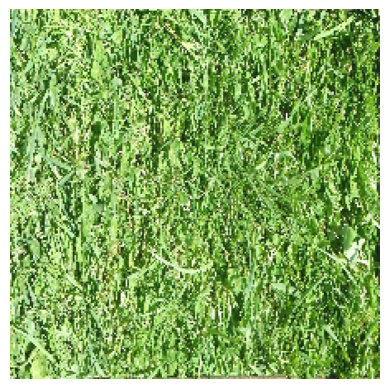

In [112]:
img = load_image(train_df.iloc[0]['full_image_path'])
aug = augment_image(img)

print("min:", tf.reduce_min(aug).numpy())
print("max:", tf.reduce_max(aug).numpy())

plt.imshow(aug.numpy())
plt.axis("off")
plt.show()


In [113]:
train_ds = make_dataset(train_df, training=True)
val_ds   = make_dataset(val_df, training=False)


In [114]:
TRAINING = False
if TRAINING:
    image_input = layers.Input(shape=(*IMG_SIZE, 3), name="image_input")

    x = layers.Conv2D(32, 3, padding='same', use_bias=False)(image_input)
    x = layers.ELU()(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(64, 3, padding='same', use_bias=False)(x)
    x = layers.ELU()(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(128, 3, padding='same', use_bias=False)(x)
    x = layers.ELU()(x)

    x = layers.GlobalAveragePooling2D()(x)

    tabular_input = layers.Input(shape=(len(TABULAR_COLS),), name="tabular_input")

    t = layers.Dense(64, use_bias=False)(tabular_input)
    t = layers.ReLU()(t)

    t = layers.Dense(64, use_bias=False)(t)
    t = layers.ReLU()(t)

    combined = layers.concatenate([x, t])

    combined = layers.Dense(64, use_bias=False)(combined)
    combined = layers.ReLU()(combined)

    output = layers.Dense(1, name="regression_output")(combined)


    model = models.Model(
        inputs=[image_input, tabular_input],
        outputs=output
    )

    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-3),
        loss='mse'
    )

    model.summary()


    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=20
    )
    model.save('biomass_model_Aug.keras')
else:
    model = tf.keras.models.load_model('biomass_model_Aug.keras')
    print("Model loaded from disk.")

Model loaded from disk.


In [115]:
y_true = []
y_pred = []

for (img, tab), y in val_ds:
    preds = model.predict((img, tab), verbose=0)
    y_true.append(y.numpy())
    y_pred.append(preds.flatten())

y_true = np.concatenate(y_true)
y_pred = np.concatenate(y_pred)


In [116]:
y_true_real = np.expm1(y_true)
y_pred_real = np.expm1(y_pred)


In [117]:
rmse = np.sqrt(mean_squared_error(y_true_real, y_pred_real))
print("Validation RMSE:", rmse)

Validation RMSE: 11.257222887491919


In [118]:
r2 = r2_score(y_true_real, y_pred_real)
print("Validation R²:", r2)

Validation R²: 0.8098780512809753


# **Introducing BatchNormalisation, L2 and EarlyStopping** 

In [119]:
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.callbacks import EarlyStopping


In [120]:
TRAINING = False
if TRAINING:
    l2_reg = regularizers.l2(1e-4)

    image_input = layers.Input(shape=(*IMG_SIZE, 3), name="image_input")

    x = layers.Conv2D(32, 3, padding='same', use_bias=False,
                    kernel_regularizer=l2_reg)(image_input)
    x = layers.BatchNormalization()(x)
    x = layers.ELU()(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(64, 3, padding='same', use_bias=False,
                    kernel_regularizer=l2_reg)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ELU()(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(128, 3, padding='same', use_bias=False,
                    kernel_regularizer=l2_reg)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ELU()(x)

    x = layers.GlobalAveragePooling2D()(x)

    tabular_input = layers.Input(shape=(len(TABULAR_COLS),), name="tabular_input")

    t = layers.Dense(128, use_bias=False,
                    kernel_regularizer=l2_reg)(tabular_input)
    t = layers.BatchNormalization()(t)
    t = layers.ReLU()(t)

    t = layers.Dense(64, use_bias=False,
                    kernel_regularizer=l2_reg)(t)
    t = layers.BatchNormalization()(t)
    t = layers.ReLU()(t)


    combined = layers.concatenate([x, t])

    combined = layers.Dense(64, use_bias=False,
                            kernel_regularizer=l2_reg)(combined)
    combined = layers.BatchNormalization()(combined)
    combined = layers.ReLU()(combined)

    output = layers.Dense(1, name="regression_output")(combined)

    model = models.Model(
        inputs=[image_input, tabular_input],
        outputs=output
    )

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=3e-4),
        loss="mse",
        metrics=[
            tf.keras.metrics.RootMeanSquaredError(name="rmse")
        ]
    )

    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True,
        verbose=1
    )

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=100,
        callbacks=[early_stop]
    )
    model.save('biomass_model_mse_L2&BatchEarly.keras')
else:
    model = tf.keras.models.load_model('biomass_model_mse_L2&BatchEarly.keras')
    print("Model loaded from disk.")

Model loaded from disk.


In [121]:
y_true = []
y_pred = []

for (img, tab), y in val_ds:
    preds = model.predict((img, tab), verbose=0)
    y_true.append(y.numpy())
    y_pred.append(preds.flatten())

y_true = np.concatenate(y_true)
y_pred = np.concatenate(y_pred)


In [122]:
y_true_real = np.expm1(y_true)
y_pred_real = np.expm1(y_pred)
rmse = np.sqrt(mean_squared_error(y_true_real, y_pred_real))
print("Validation RMSE:", rmse)
r2 = r2_score(y_true_real, y_pred_real)
print("Validation R²:", r2)

Validation RMSE: 12.201508750802027
Validation R²: 0.7766444087028503


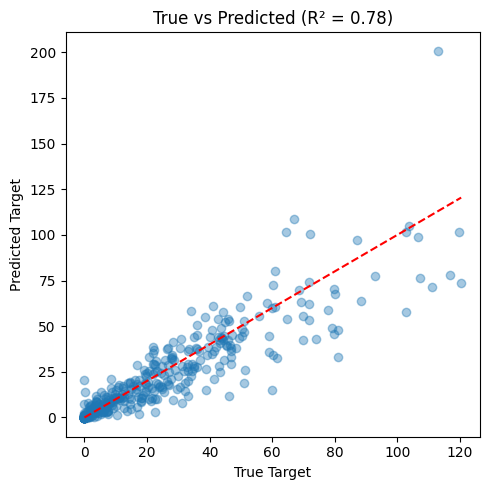

In [123]:
plt.figure(figsize=(5,5))
plt.scatter(y_true_real, y_pred_real, alpha=0.4)
plt.plot(
    [y_true_real.min(), y_true_real.max()],
    [y_true_real.min(), y_true_real.max()],
    'r--'
)
plt.xlabel("True Target")
plt.ylabel("Predicted Target")
plt.title(f"True vs Predicted (R² = {r2:.2f})")
plt.tight_layout()
plt.show()


In [77]:
for name in df['target_name'].unique():
    idx = val_df['target_name'] == name
    r2 = r2_score(y_true_real[idx], y_pred_real[idx])
    print(name, "R²:", round(r2, 3))


Dry_Clover_g R²: 0.526
Dry_Dead_g R²: 0.383
Dry_Green_g R²: 0.677
Dry_Total_g R²: 0.666
GDM_g R²: 0.78


# **Increaing layer and Huber as lose function**

In [78]:
TRAINING = False
if TRAINING:
    l2_reg = regularizers.l2(1e-4)

    image_input = layers.Input(shape=(*IMG_SIZE, 3), name="image_input")

    x = layers.Conv2D(32, 3, padding='same', use_bias=False,
                    kernel_regularizer=l2_reg)(image_input)
    x = layers.BatchNormalization()(x)
    x = layers.ELU()(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(64, 3, padding='same', use_bias=False,
                    kernel_regularizer=l2_reg)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ELU()(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(128, 3, padding='same', use_bias=False,
                    kernel_regularizer=l2_reg)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ELU()(x)

    x = layers.Conv2D(256, 3, padding='same', use_bias=False,
                    kernel_regularizer=l2_reg)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ELU()(x)

    x = layers.GlobalAveragePooling2D()(x)

    tabular_input = layers.Input(shape=(len(TABULAR_COLS),), name="tabular_input")

    t = layers.Dense(128, use_bias=False,
                    kernel_regularizer=l2_reg)(tabular_input)
    t = layers.BatchNormalization()(t)
    t = layers.ReLU()(t)

    t = layers.Dense(64, use_bias=False,
                    kernel_regularizer=l2_reg)(t)
    t = layers.BatchNormalization()(t)
    t = layers.ReLU()(t)


    combined = layers.concatenate([x, t])

    combined = layers.Dense(64, use_bias=False,
                            kernel_regularizer=l2_reg)(combined)
    combined = layers.BatchNormalization()(combined)
    combined = layers.ReLU()(combined)

    combined = layers.Dense(32, use_bias=False,
                            kernel_regularizer=l2_reg)(combined)
    combined = layers.BatchNormalization()(combined)
    combined = layers.ReLU()(combined)

    output = layers.Dense(1, name="regression_output2")(combined)

    model = models.Model(
        inputs=[image_input, tabular_input],
        outputs=output
    )

    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-3),
        loss=tf.keras.losses.Huber(delta=10.0)
    )

    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True,
        verbose=1
    )

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=100,
        callbacks=[early_stop]
    )
    model.save('biomass_model_HuberLoss.keras')
else:
    model = tf.keras.models.load_model('biomass_model_HuberLoss.keras')
    print("Model loaded from disk.")

Model loaded from disk.


In [124]:
y_true = []
y_pred = []

for (img, tab), y in val_ds:
    preds = model.predict((img, tab), verbose=0)
    y_true.append(y.numpy())
    y_pred.append(preds.flatten())

y_true = np.concatenate(y_true)
y_pred = np.concatenate(y_pred)

y_true_real = np.expm1(y_true)
y_pred_real = np.expm1(y_pred)
rmse = np.sqrt(mean_squared_error(y_true_real, y_pred_real))
print("Validation RMSE:", rmse)
r2 = r2_score(y_true_real, y_pred_real)
print("Validation R²:", r2)

Validation RMSE: 12.201508750802027
Validation R²: 0.7766444087028503


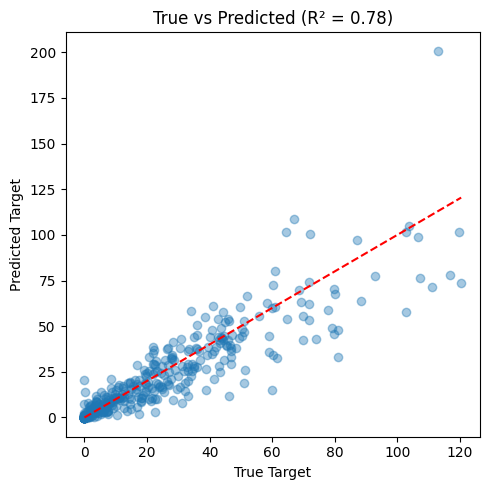

In [125]:
plt.figure(figsize=(5,5))
plt.scatter(y_true_real, y_pred_real, alpha=0.4)
plt.plot(
    [y_true_real.min(), y_true_real.max()],
    [y_true_real.min(), y_true_real.max()],
    'r--'
)
plt.xlabel("True Target")
plt.ylabel("Predicted Target")
plt.title(f"True vs Predicted (R² = {r2:.2f})")
plt.tight_layout()
plt.show()


# **To Improve the result swiching loss fucntion to Log Cosh for a better smooth and robust value**

In [126]:
TRAINING = False
if TRAINING:
    l2_reg = regularizers.l2(1e-4)

    image_input = layers.Input(shape=(*IMG_SIZE, 3), name="image_input")

    x = layers.Conv2D(32, 3, padding='same', use_bias=False,
                    kernel_regularizer=l2_reg)(image_input)
    x = layers.BatchNormalization()(x)
    x = layers.ELU()(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(64, 3, padding='same', use_bias=False,
                    kernel_regularizer=l2_reg)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ELU()(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(128, 3, padding='same', use_bias=False,
                    kernel_regularizer=l2_reg)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ELU()(x)

    x = layers.Conv2D(256, 3, padding='same', use_bias=False,
                    kernel_regularizer=l2_reg)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ELU()(x)

    x = layers.GlobalAveragePooling2D()(x)

    tabular_input = layers.Input(shape=(len(TABULAR_COLS),), name="tabular_input")

    t = layers.Dense(128, use_bias=False,
                    kernel_regularizer=l2_reg)(tabular_input)
    t = layers.BatchNormalization()(t)
    t = layers.ReLU()(t)

    t = layers.Dense(64, use_bias=False,
                    kernel_regularizer=l2_reg)(t)
    t = layers.BatchNormalization()(t)
    t = layers.ReLU()(t)


    combined = layers.concatenate([x, t])

    combined = layers.Dense(64, use_bias=False,
                            kernel_regularizer=l2_reg)(combined)
    combined = layers.BatchNormalization()(combined)
    combined = layers.ELU()(combined)

    combined = layers.Dense(32, use_bias=False,
                            kernel_regularizer=l2_reg)(combined)
    combined = layers.BatchNormalization()(combined)
    combined = layers.ELU()(combined)

    output = layers.Dense(1, name="regression_output2")(combined)

    model = models.Model(
        inputs=[image_input, tabular_input],
        outputs=output
    )

    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-3),
        loss=tf.keras.losses.LogCosh()
    )

    EarlyStopping(
        monitor='val_loss',
        patience=6,
        restore_best_weights=True
    )

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=100,
        callbacks=[early_stop]
    )
    
    model.save('biomass_model_LogCosh.keras')
else:
    model = tf.keras.models.load_model('biomass_model_LogCosh.keras')
    print("Model loaded from disk.")

Model loaded from disk.


In [127]:
y_true = []
y_pred = []

for (img, tab), y in val_ds:
    preds = model.predict((img, tab), verbose=0)
    y_true.append(y.numpy())
    y_pred.append(preds.flatten())

y_true = np.concatenate(y_true)
y_pred = np.concatenate(y_pred)

y_true_real = np.expm1(y_true)
y_pred_real = np.expm1(y_pred)
rmse = np.sqrt(mean_squared_error(y_true_real, y_pred_real))
print("Validation RMSE:", rmse)
r2 = r2_score(y_true_real, y_pred_real)
print("Validation R²:", r2)


Validation RMSE: 9.117635603142912
Validation R²: 0.875280499458313


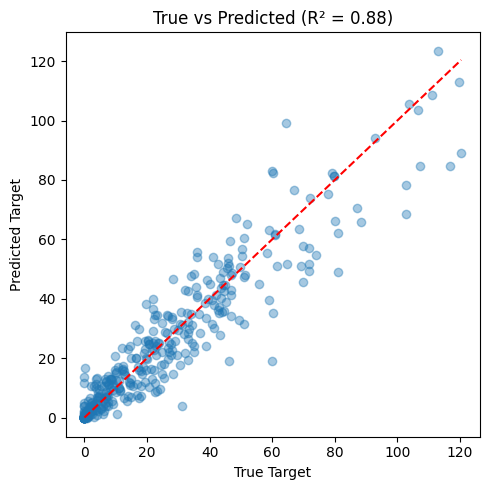

In [128]:
plt.figure(figsize=(5,5))
plt.scatter(y_true_real, y_pred_real, alpha=0.4)
plt.plot(
    [y_true_real.min(), y_true_real.max()],
    [y_true_real.min(), y_true_real.max()],
    'r--'
)
plt.xlabel("True Target")
plt.ylabel("Predicted Target")
plt.title(f"True vs Predicted (R² = {r2:.2f})")
plt.tight_layout()
plt.show()

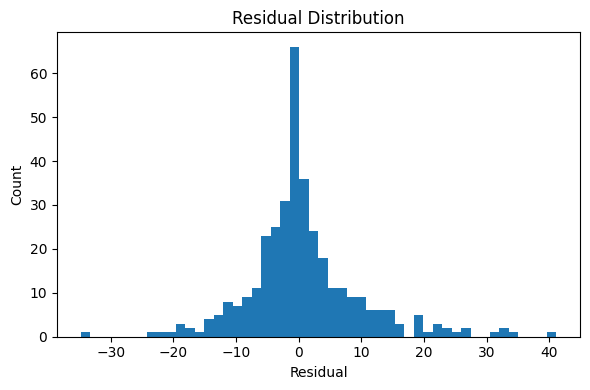

In [129]:
residuals = y_true_real - y_pred_real
plt.figure(figsize=(6,4))
plt.hist(residuals, bins=50)
plt.xlabel("Residual")
plt.ylabel("Count")
plt.title("Residual Distribution")
plt.tight_layout()
plt.show()


# ***Ensembling the first 3 models***

In [130]:
mse_model   = tf.keras.models.load_model("biomass_model_mse_L2&BatchEarly.keras")
huber_model = tf.keras.models.load_model("biomass_model_HuberLoss.keras")
log_model   = tf.keras.models.load_model("biomass_model_LogCosh.keras")


In [131]:
TARGET_WEIGHTS = {
    "Dry_Green_g": 0.1,
    "Dry_Dead_g": 0.1,
    "Dry_Clover_g": 0.1,
    "GDM_g": 0.2,
    "Dry_Total_g": 0.5
}


In [132]:
def process(path, tab, y, training=False):
    img = load_image(path)

    if training:
        img = augment_image(img)

    return (img, tab), y

def make_dataset(df, training=True):
    img_paths = df['full_image_path'].values
    tabular = df[TABULAR_COLS].values
    targets = df['target_log'].values

    ds = tf.data.Dataset.from_tensor_slices((img_paths, tabular, targets))

    ds = ds.map(
        lambda p, t, y: process(p, t, y, training),
        num_parallel_calls=tf.data.AUTOTUNE
    )

    if training:
        ds = ds.shuffle(1024)

    return ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

train_ds = make_dataset(train_df, training=True)
val_ds   = make_dataset(val_df, training=False)


In [133]:
val_weights = val_df["target_name"].map(TARGET_WEIGHTS).values

In [134]:
MODEL_WEIGHTS = np.array([0.1, 0.35, 0.55])  # [mse_model, huber_model, logcosh_model]


In [135]:
def ensemble_predict_log(models, model_weights, img, tab):
    preds = [
        m.predict((img, tab), verbose=0).flatten()
        for m in models
    ]
    return np.average(preds, axis=0, weights=model_weights)


In [136]:
def evaluate_weighted_ensemble_rmse(models, model_weights, val_ds):
    y_true, y_pred = [], []

    for (img, tab), y in val_ds:
        pred_log = ensemble_predict_log(models, model_weights, img, tab)

        y_true.append(y.numpy())
        y_pred.append(pred_log)

    y_true = np.expm1(np.concatenate(y_true))
    y_pred = np.expm1(np.concatenate(y_pred))

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return rmse


In [137]:
rmse_ens = evaluate_weighted_ensemble_rmse(
    [mse_model, huber_model, log_model],
    MODEL_WEIGHTS,
    val_ds
)

print("Weighted Ensemble RMSE:", rmse_ens)


Weighted Ensemble RMSE: 9.210125915074313


In [138]:
import numpy as np

def weighted_r2(y_true, y_pred, weights):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    weights = np.asarray(weights)

    y_bar = np.sum(weights * y_true) / np.sum(weights)

    ss_res = np.sum(weights * (y_true - y_pred) ** 2)
    ss_tot = np.sum(weights * (y_true - y_bar) ** 2)

    return 1 - ss_res / ss_tot


In [139]:
def evaluate_kaggle_r2(model, val_ds, weights):
    y_true, y_pred = [], []

    for (img, tab), y in val_ds:
        p = model.predict((img, tab), verbose=0)
        y_true.append(y.numpy())
        y_pred.append(p.flatten())

    y_true = np.expm1(np.concatenate(y_true))
    y_pred = np.expm1(np.concatenate(y_pred))

    return weighted_r2(y_true, y_pred, weights)


In [140]:
print("Kaggle R² (MSE):",
      evaluate_kaggle_r2(mse_model, val_ds, val_weights))

print("Kaggle R² (Huber):",
      evaluate_kaggle_r2(huber_model, val_ds, val_weights))

print("Kaggle R² (LogCosh):",
      evaluate_kaggle_r2(log_model, val_ds, val_weights))

Kaggle R² (MSE): 0.7391499003613962
Kaggle R² (Huber): 0.786853750064749
Kaggle R² (LogCosh): 0.8550427095544881


In [141]:
pred_mse_log   = mse_model.predict(val_ds).flatten()
pred_huber_log = huber_model.predict(val_ds).flatten()
pred_log_log   = log_model.predict(val_ds).flatten()

# Convert back from log scale
pred_mse_real   = np.expm1(pred_mse_log)
pred_huber_real = np.expm1(pred_huber_log)
pred_log_real   = np.expm1(pred_log_log)


12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 386ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 8s 586ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 8s 607ms/step


In [142]:
pred_ens_real = (
    pred_mse_real +
    pred_huber_real +
    pred_log_real
) / 3


In [143]:
y_true_log = np.concatenate([y.numpy() for _, y in val_ds])
y_true_real = np.expm1(y_true_log)


In [144]:
val_weights = val_df["target_name"].map(TARGET_WEIGHTS).values


In [145]:
def evaluate_ensemble_rmse(models, val_ds):
    y_true, y_pred = [], []

    for (img, tab), y in val_ds:
        batch_preds = [
            m.predict((img, tab), verbose=0).flatten()
            for m in models
        ]

        avg_pred = np.mean(batch_preds, axis=0)

        y_true.append(y.numpy())
        y_pred.append(avg_pred)

    y_true = np.expm1(np.concatenate(y_true))
    y_pred = np.expm1(np.concatenate(y_pred))

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return rmse


In [146]:
def evaluate_weighted_ensemble_r2(
    models,
    model_weights,
    val_ds,
    val_target_names,
    target_weights_dict
):
    y_true, y_pred = [], []

    for (img, tab), y in val_ds:
        pred_log = ensemble_predict_log(models, model_weights, img, tab)

        y_true.append(y.numpy())
        y_pred.append(pred_log)

    y_true = np.expm1(np.concatenate(y_true))
    y_pred = np.expm1(np.concatenate(y_pred))

    row_weights = np.array(
        val_target_names.map(target_weights_dict)
    )

    return weighted_r2(y_true, y_pred, row_weights)


In [147]:
ensemble_r2 = evaluate_weighted_ensemble_r2(
    models=[mse_model, huber_model, log_model],
    model_weights=MODEL_WEIGHTS,
    val_ds=val_ds,
    val_target_names=val_df["target_name"],
    target_weights_dict=TARGET_WEIGHTS
)

print("Weighted Ensemble R²:", ensemble_r2)


Weighted Ensemble R²: 0.8582213576429853


In [148]:
np.save("ensemble_weights.npy", MODEL_WEIGHTS)


**Kaggle R² (LogCosh): 0.8550427095544881**




**Weighted Ensemble R²: 0.8582213576429853**

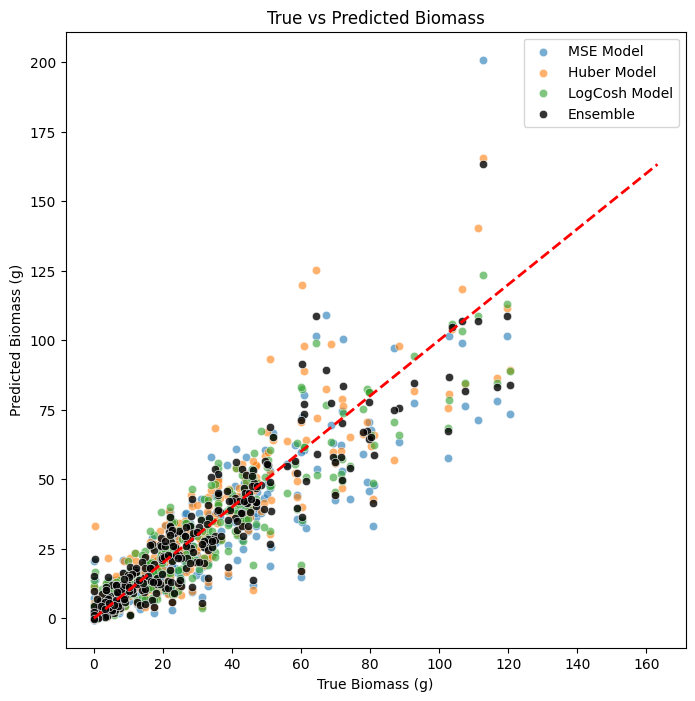

In [149]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 8))

# Scatter plots
sns.scatterplot(x=y_true_real, y=pred_mse_real, label="MSE Model", alpha=0.6)
sns.scatterplot(x=y_true_real, y=pred_huber_real, label="Huber Model", alpha=0.6)
sns.scatterplot(x=y_true_real, y=pred_log_real, label="LogCosh Model", alpha=0.6)
sns.scatterplot(x=y_true_real, y=pred_ens_real, label="Ensemble", alpha=0.8, color='black')

# Diagonal line
max_val = max(y_true_real.max(), pred_ens_real.max())
plt.plot([0, max_val], [0, max_val], 'r--', lw=2)

plt.xlabel("True Biomass (g)")
plt.ylabel("Predicted Biomass (g)")
plt.title("True vs Predicted Biomass")
plt.legend()
plt.show()


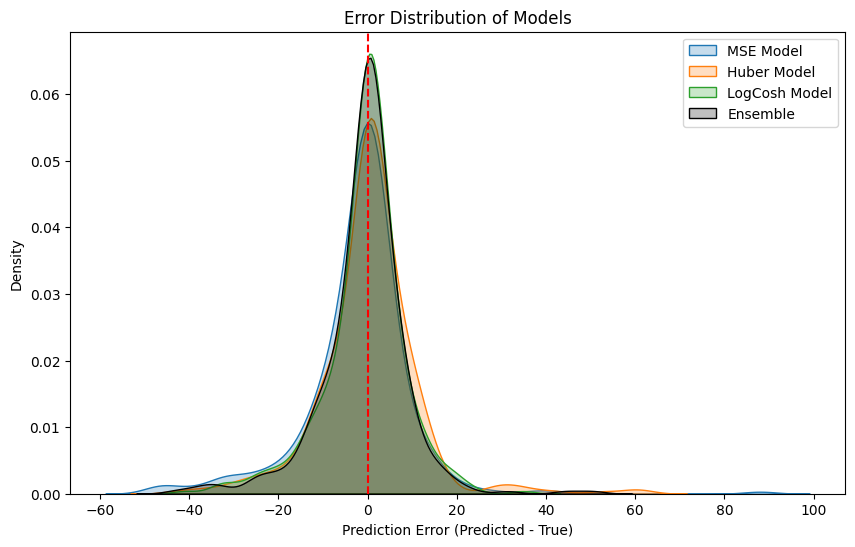

In [150]:
errors_mse   = pred_mse_real - y_true_real
errors_huber = pred_huber_real - y_true_real
errors_log   = pred_log_real - y_true_real
errors_ens   = pred_ens_real - y_true_real

plt.figure(figsize=(10, 6))
sns.kdeplot(errors_mse, label="MSE Model", fill=True)
sns.kdeplot(errors_huber, label="Huber Model", fill=True)
sns.kdeplot(errors_log, label="LogCosh Model", fill=True)
sns.kdeplot(errors_ens, label="Ensemble", fill=True, color='black')

plt.axvline(0, color='r', linestyle='--')
plt.xlabel("Prediction Error (Predicted - True)")
plt.ylabel("Density")
plt.title("Error Distribution of Models")
plt.legend()
plt.show()


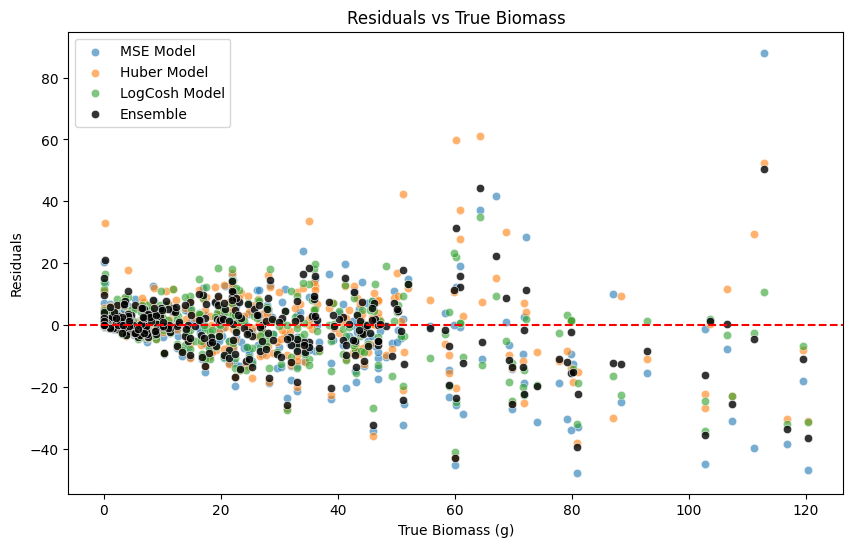

In [151]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_true_real, y=errors_mse, label="MSE Model", alpha=0.6)
sns.scatterplot(x=y_true_real, y=errors_huber, label="Huber Model", alpha=0.6)
sns.scatterplot(x=y_true_real, y=errors_log, label="LogCosh Model", alpha=0.6)
sns.scatterplot(x=y_true_real, y=errors_ens, label="Ensemble", alpha=0.8, color='black')

plt.axhline(0, color='r', linestyle='--')
plt.xlabel("True Biomass (g)")
plt.ylabel("Residuals")
plt.title("Residuals vs True Biomass")
plt.legend()
plt.show()


C:\Users\Acer\AppData\Local\Temp\ipykernel_2828\3985269176.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


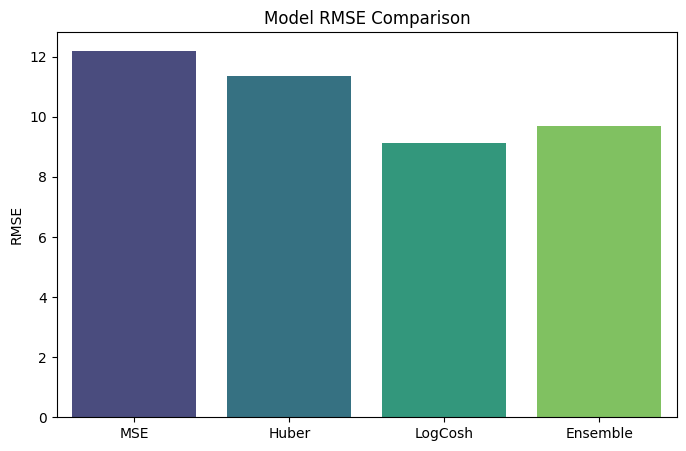

In [152]:
from sklearn.metrics import mean_squared_error

rmse_mse   = np.sqrt(mean_squared_error(y_true_real, pred_mse_real))
rmse_huber = np.sqrt(mean_squared_error(y_true_real, pred_huber_real))
rmse_log   = np.sqrt(mean_squared_error(y_true_real, pred_log_real))
rmse_ens   = np.sqrt(mean_squared_error(y_true_real, pred_ens_real))

plt.figure(figsize=(8, 5))
sns.barplot(
    x=["MSE", "Huber", "LogCosh", "Ensemble"],
    y=[rmse_mse, rmse_huber, rmse_log, rmse_ens],
    palette="viridis"
)
plt.ylabel("RMSE")
plt.title("Model RMSE Comparison")
plt.show()


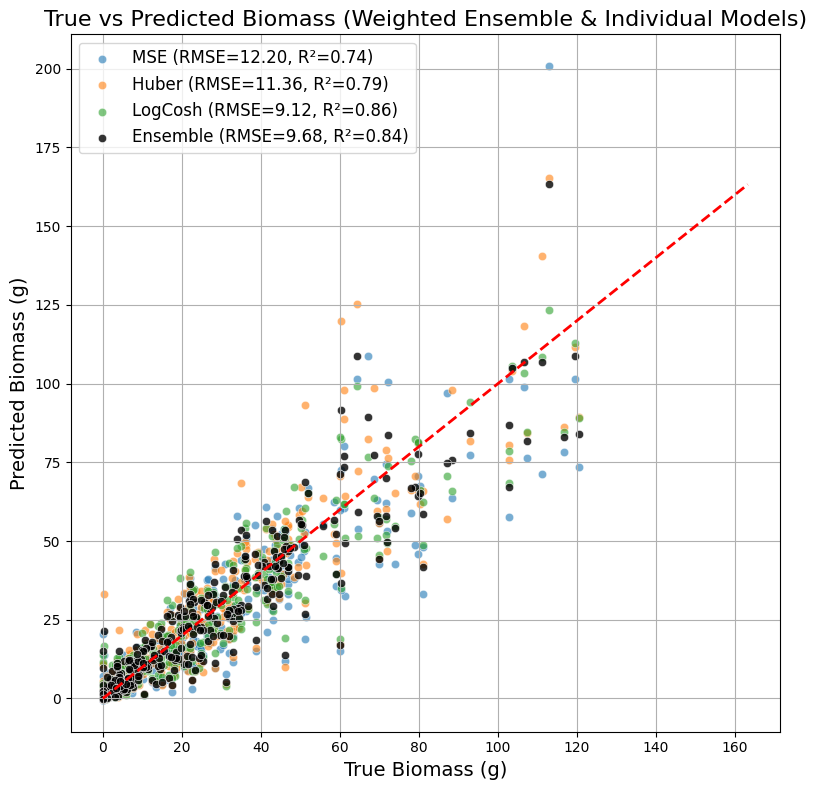

In [153]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error

# Calculate RMSE and R² for each model
def compute_metrics(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = weighted_r2(y_true, y_pred, val_weights)  # use your weighted R² function
    return rmse, r2

metrics = {
    "MSE": compute_metrics(y_true_real, pred_mse_real),
    "Huber": compute_metrics(y_true_real, pred_huber_real),
    "LogCosh": compute_metrics(y_true_real, pred_log_real),
    "Ensemble": compute_metrics(y_true_real, pred_ens_real)
}

plt.figure(figsize=(8, 8))

# Scatter plots
sns.scatterplot(x=y_true_real, y=pred_mse_real, label=f"MSE (RMSE={metrics['MSE'][0]:.2f}, R²={metrics['MSE'][1]:.2f})", alpha=0.6)
sns.scatterplot(x=y_true_real, y=pred_huber_real, label=f"Huber (RMSE={metrics['Huber'][0]:.2f}, R²={metrics['Huber'][1]:.2f})", alpha=0.6)
sns.scatterplot(x=y_true_real, y=pred_log_real, label=f"LogCosh (RMSE={metrics['LogCosh'][0]:.2f}, R²={metrics['LogCosh'][1]:.2f})", alpha=0.6)
sns.scatterplot(x=y_true_real, y=pred_ens_real, label=f"Ensemble (RMSE={metrics['Ensemble'][0]:.2f}, R²={metrics['Ensemble'][1]:.2f})", alpha=0.8, color='black')

# Diagonal line for perfect predictions
max_val = max(y_true_real.max(), pred_ens_real.max())
plt.plot([0, max_val], [0, max_val], 'r--', lw=2)

plt.xlabel("True Biomass (g)", fontsize=14)
plt.ylabel("Predicted Biomass (g)", fontsize=14)
plt.title("True vs Predicted Biomass (Weighted Ensemble & Individual Models)", fontsize=16)
plt.legend(loc='upper left', fontsize=12)
plt.tight_layout()
plt.grid(True)
plt.show()


# **Conclusion**

Model made using Log Cosh Error is the best model then the ensemble model

# **Testing**

In [154]:
def prepare_test_df(test_df, tabular_cols):
    df = test_df.copy()

    # full image path (same pattern as training)
    df["full_image_path"] = df["image_path"].apply(
        lambda x: os.path.join("data", x)
    )

    # ---------- target one-hot ----------
    tgt_dummies = pd.get_dummies(df["target_name"], prefix="tgt")
    df = pd.concat([df, tgt_dummies], axis=1)

    # ---------- add ALL missing columns ----------
    for col in tabular_cols:
        if col not in df.columns:
            df[col] = 0.0

    # ---------- enforce correct order ----------
    df = df[["full_image_path"] + tabular_cols]

    df[tabular_cols] = df[tabular_cols].astype("float32")

    return df


In [155]:
test_df = pd.read_csv("data/test.csv")

test_df = prepare_test_df(
    test_df,
    tabular_cols=TABULAR_COLS
)

def make_test_dataset(df):
    img_paths = df["full_image_path"].values
    tabular = df[TABULAR_COLS].values

    ds = tf.data.Dataset.from_tensor_slices((img_paths, tabular))

    ds = ds.map(
        lambda p, t: (load_image(p), t),
        num_parallel_calls=tf.data.AUTOTUNE
    )

    return ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

test_ds = make_test_dataset(test_df)


In [156]:
def ensemble_predict_test(models, weights, test_ds):
    preds = []

    for img, tab in test_ds:
        batch_preds = [
            m.predict((img, tab), verbose=0).flatten()
            for m in models
        ]
        preds.append(
            np.average(batch_preds, axis=0, weights=weights)
        )

    preds = np.concatenate(preds)
    preds = np.expm1(preds)  # back from log scale
    return preds


In [157]:
test_preds_log = ensemble_predict_test(
    models=[mse_model, huber_model, log_model],
    weights=MODEL_WEIGHTS,
    test_ds=test_ds
)

test_preds = np.expm1(test_preds_log)


In [159]:
print("Test Predictions:", test_preds)

Test Predictions: [2.25259872e-01 7.95955547e+00 2.84192094e+00 5.83466391e+03
 1.23582152e+01]


In [161]:
def ensemble_predict_log_ds(models, model_weights, ds):
    preds = []

    for img, tab in ds:
        batch_preds = [
            m.predict((img, tab), verbose=0).flatten()
            for m in models
        ]
        preds.append(
            np.average(batch_preds, axis=0, weights=model_weights)
        )

    return np.concatenate(preds)


In [168]:
pred_log = ensemble_predict_log_ds(
    [mse_model, huber_model, log_model],
    MODEL_WEIGHTS,
    test_ds
)

print(pred_log.round(2))


pred_real = np.expm1(pred_log)
print(f"Predictions: {pred_real.round(2)}")



[0.18 1.16 0.85 2.27 1.28]
Predictions: [0.2  2.19 1.35 8.67 2.59]


In [177]:
pred_log_mse = []
pred_log_huber = []
pred_log_logcosh = []

for img, tab in test_ds:
    pred_log_mse.append(
        mse_model.predict((img, tab), verbose=0).flatten()
    )
    pred_log_huber.append(
        huber_model.predict((img, tab), verbose=0).flatten()
    )
    pred_log_logcosh.append(
        log_model.predict((img, tab), verbose=0).flatten()
    )

pred_log_mse      = np.concatenate(pred_log_mse)
pred_log_huber    = np.concatenate(pred_log_huber)
pred_log_logcosh  = np.concatenate(pred_log_logcosh)


In [178]:
pred_real_mse      = np.expm1(pred_log_mse)
pred_real_huber    = np.expm1(pred_log_huber)
pred_real_logcosh  = np.expm1(pred_log_logcosh)


In [181]:
MODEL_WEIGHTS = np.array([0.1, 0.4, 0.5])  # same as validation

pred_log_ensemble = np.average(
    np.vstack([
        pred_log_mse,
        pred_log_huber,
        pred_log_logcosh
    ]),
    axis=0,
    weights=MODEL_WEIGHTS
)

pred_real_ensemble = np.expm1(pred_log_ensemble)


In [182]:
print("MSE Model Predictions:",      pred_real_mse.round(2))
print("Huber Model Predictions:",    pred_real_huber.round(2))
print("LogCosh Model Predictions:",  pred_real_logcosh.round(2))
print("Ensemble Predictions:",       pred_real_ensemble.round(2))


MSE Model Predictions: [0.14 1.11 0.81 2.52 1.93]
Huber Model Predictions: [0.19 1.48 1.81 9.6  3.58]
LogCosh Model Predictions: [0.22 3.04 1.19 9.97 2.19]
Ensemble Predictions: [0.2  2.12 1.38 8.66 2.66]


In [185]:
test_df.head()

,full_image_path,Pre_GSHH_NDVI,Height_Ave_cm,tgt_Dry_Clover_g,tgt_Dry_Dead_g,tgt_Dry_Green_g,tgt_Dry_Total_g,tgt_GDM_g,state_NSW,state_Tas,...,month_1,month_2,month_4,month_5,month_6,month_7,month_8,month_9,month_10,month_11
0,data\test/ID1001187975.jpg,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,data\test/ID1001187975.jpg,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,data\test/ID1001187975.jpg,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,data\test/ID1001187975.jpg,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,data\test/ID1001187975.jpg,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [186]:
test_csv = pd.read_csv("data/test.csv")


In [190]:
submission = test_csv[["sample_id"]].copy()
submission["target"] = pred_real_ensemble.round(3)


In [191]:
submission.to_csv("submission.csv", index=False)
